# WDM -- Single-Stage Coupler Lattice Filter (N=2 / N=4, Ideal + Real-FDTD + GDS)

This notebook is the complete, consolidated design record for the single-stage
cascaded-coupler lattice filter -- the building block reused by
`wdm_mux4_sax.ipynb`'s 2-stage binary-tree demultiplexer. It follows the same
7-section structure as that notebook: analytical (SAX) model first, then the
real-FDTD-measured model built from cached component S-parameters, a direct
comparison between the two, and finally a GDSfactory physical layout.

**Do not use "Run All."** Stop and look at each plot before trusting the next
step.

## 1. Introduction

A **lattice filter** cascades $N$ directional couplers, joined by $N-1$ delay
arms that all share one path-length difference $\Delta L$ -- the classical
architecture behind CWDM (de)multiplexers (e.g. Luceda Photonics'
[`mux2` tutorial](https://academy.lucedaphotonics.com/training/topical_training/wdm_transmitter_mzi/mux2)).
$N=2$ (two couplers, one delay arm) is the trivial case -- an ordinary MZI, a
plain sinusoidal transmission with no flat region anywhere. $N=4$ synthesizes
the 4 couplers' power-coupling ratios for a **maximally-flat (halfband)**
passband, widening the usable flat-top around each transmission peak.

This notebook builds and compares BOTH the **ideal, analytic** model (lossless,
exactly-50:50-where-intended couplers and dispersion-corrected arms) and the
**real, FDTD-measured** model (genuine directional-coupler and delay-arm
S-parameters from `06_directional_coupler.ipynb`/`03_mzi_arm.ipynb`), for both
$N=2$ and $N=4$, ending with a full GDSfactory physical layout of both designs.

## 2. Circuit design with SAX -- analytical model (N=2, N=4)

Each lattice stage's phase depends on the round-trip phase difference between
its two arms,
$$\phi(\lambda) = \frac{2\pi\, n_{\mathrm{eff}}(\lambda)\, \Delta L}{\lambda},$$
and the filter repeats with a free spectral range set by
$$\Delta L = \frac{\lambda_0^2}{n_g \cdot \mathrm{FSR}}$$
(the same relation `07_mzi.ipynb` Section 10-11 already fits from measured
fringe spacing).

Rather than target FSR directly, `delta_L_um=15.0` is chosen **first**, to land
exactly on `07_mzi.ipynb`'s own already-simulated `delta_L_um` sweep point
(`data/sparams/mzi/sweep/mzi_deltaL15.0.json`) -- so the real-FDTD comparison in
Section 4 can reuse that existing run rather than needing a new one. `wl0_um`,
`n_eff0`, and `n_g0` are pulled from that same notebook's own cached Section
10-11 output at `1.35um`: `n_eff0=2.4085` (phase index, from MPB arm dispersion)
and `n_g0=2.763` (group index, from the FDTD S21 fringe-spacing fit -- not the
MPB-dispersion group-index estimate, `~2.928`, which characterizes only a
straight arm segment rather than the full round-trip through both couplers'
S-bends).

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pic_toolkit import style
from pic_toolkit.circuits import mzi_lattice as ml

style.apply_style()
%matplotlib inline

# ============================================================
# USER PARAMETERS
# ============================================================
WL0_UM = 1.35        # design center wavelength -- matches this toolkit's convention
                      # (waveguide.yaml/07_mzi.ipynb are both characterized at 1.35um)
N_EFF0 = 2.4085       # phase index at WL0_UM, from 07_mzi.ipynb's MPB arm dispersion
N_G0 = 2.763          # group index at WL0_UM, from 07_mzi.ipynb's FDTD FSR-fit (Section 10)
DELTA_L_UM = 15.0     # design target -- matches 07_mzi.ipynb's own delta_L sweep point

fsr_nm = ml.delta_L_um_to_fsr(DELTA_L_UM, WL0_UM, N_G0) * 1000
print(f"delta_L_um = {DELTA_L_UM} -> FSR = {fsr_nm:.2f} nm (target was ~40nm)")

delta_L_um = 15.0 -> FSR = 43.97 nm (target was ~40nm)


/home/yuma/miniconda3/envs/mp/lib/python3.10/site-packages/sax/backends/__init__.py:78: UserWarning: klujax not found. Please install klujax for better performance during circuit evaluation!
  warnings.warn(


### Ideal building blocks

Every coupler is an ideal, lossless 2x2 splitter with power-coupling ratio $\kappa$:
$$
\begin{pmatrix}E_{\text{out,top}}\\E_{\text{out,bot}}\end{pmatrix} =
\begin{pmatrix}\sqrt{1-\kappa} & i\,\mathrm{sign}\sqrt{\kappa}\\
i\,\mathrm{sign}\sqrt{\kappa} & \sqrt{1-\kappa}\end{pmatrix}
\begin{pmatrix}E_{\text{in,top}}\\E_{\text{in,bot}}\end{pmatrix},
$$
the standard $\pm90^\circ$ cross-port phase a lossless 3dB-style coupler must
carry to stay unitary (`sign=+1` unless a specific stage's synthesis needs
`-1` -- see the N=4 subsection below).

Every arm is an ideal phase delay, $S_{21}=\exp\!\left(i\,\phi(\lambda)\cdot
\frac{\text{length}}{\Delta L}\right)$ using $\phi(\lambda)$ above (only the
*difference* in length between a stage's two arms matters for this lossless
model, so one arm is fixed at length 0 and the other at `delta_L_um`).

Sanity check below: at one sample wavelength, every port's outgoing power must
sum to 1 (lossless/unitary).

In [2]:
coupler = ml.ideal_coupler_model(kappa=0.5, sign=1)
arm = ml.ideal_arm_model(length_um=DELTA_L_UM, n_eff0=N_EFF0, n_g0=N_G0, wl0_um=WL0_UM)

S_coupler = coupler(wl=WL0_UM)
S_arm = arm(wl=WL0_UM)
power_out_top = abs(S_coupler[("in_top", "out_top")]) ** 2 + abs(S_coupler[("in_top", "out_bot")]) ** 2
print(f"coupler: power out of in_top = {power_out_top:.6f} (should be 1.0)")
print(f"arm: |S21|^2 = {abs(S_arm[('in', 'out')]) ** 2:.6f} (should be 1.0)")

coupler: power out of in_top = 1.000000 (should be 1.0)
arm: |S21|^2 = 1.000000 (should be 1.0)


### N=2 -- the ordinary single MZI (baseline)

Two 50:50 couplers joined by one delay arm is just the plain MZI `07_mzi.ipynb`
already built in FDTD -- $\kappa=[0.5, 0.5]$, no synthesis needed. Its
transmission is a plain sinusoid in wavelength, with **no flat region**
anywhere: this is the baseline the N=4 lattice below is compared against.

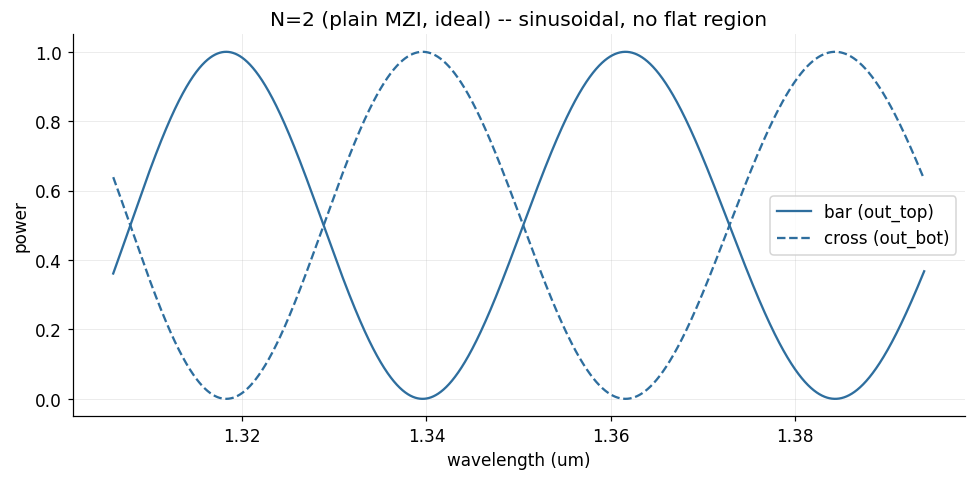

unitarity check: max|bar+cross-1| = 3.58e-07


In [3]:
fsr_um = ml.delta_L_um_to_fsr(DELTA_L_UM, WL0_UM, N_G0)
wl_sweep = jnp.linspace(WL0_UM - fsr_um, WL0_UM + fsr_um, 4000)  # ~2 FSR span

kappas_2, signs_2 = [0.5, 0.5], [1, 1]
circuit_2, _ = ml.build_lattice_circuit(kappas_2, signs_2, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)
S_2 = circuit_2(wl=wl_sweep)
bar_2 = np.abs(np.asarray(S_2[("in_top", "out_top")])) ** 2
cross_2 = np.abs(np.asarray(S_2[("in_top", "out_bot")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wl_sweep, bar_2, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(wl_sweep, cross_2, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("N=2 (plain MZI, ideal) -- sinusoidal, no flat region")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unitarity check: max|bar+cross-1| = {np.max(np.abs(bar_2 + cross_2 - 1)):.2e}")

### N=4 -- synthesized maximally-flat (halfband) lattice

Widening the passband (not just being flat at one point) is a **halfband
filter** design target: the bar-port power
$$|A(\phi)|^2 = P_K\!\left(\sin^2\frac{\phi}{2}\right), \qquad
P_K(x)=\sum_{k=K}^{2K-1}\binom{2K-1}{k}x^k(1-x)^{2K-1-k}, \qquad N=2K$$
is flat (many vanishing derivatives) at **both** $\phi=0$ and $\phi=\pi$ while
always crossing exactly 0.5 at $\phi=\pi/2$, regardless of $K$ -- so every
order shares the same -3dB crossover, and only the near-flat-top region widens
as $K$ (i.e. $N$) grows. For $N=4$ ($K=2$), $P_2(x)=3x^2-2x^3$ (the familiar
cubic "smoothstep").

The physical coupling ratios $\kappa_i$ that realize this in a real lattice
are found by a classical two-port "layer-peeling" synthesis (spectral-factor
the target into a lossless paraunitary pair, then recursively strip one
coupler at a time) -- `synthesize_maximally_flat_kappas` implements this and
verifies its own output by reconstructing the target response from the
returned $\kappa_i$ before returning them.

kappa_i: [0.9328 0.     0.7503 0.5006]
sign_i:  [1, 1, 1, -1]  (the coupler's cross-port phase convention -- see the building-blocks subsection above)


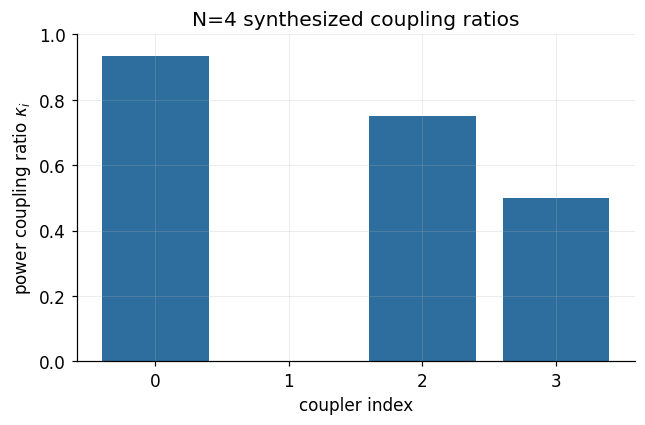

In [4]:
kappas_4, signs_4 = ml.synthesize_maximally_flat_kappas(4)
print("kappa_i:", np.round(kappas_4, 4))
print("sign_i: ", signs_4, " (the coupler's cross-port phase convention -- see the building-blocks subsection above)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(kappas_4)), kappas_4, color=style.COLOR_STEEL)
ax.set_xlabel("coupler index")
ax.set_ylabel(r"power coupling ratio $\kappa_i$")
ax.set_xticks(range(len(kappas_4)))
ax.set_ylim(0, 1)
ax.set_title("N=4 synthesized coupling ratios")
fig.tight_layout()
plt.show()

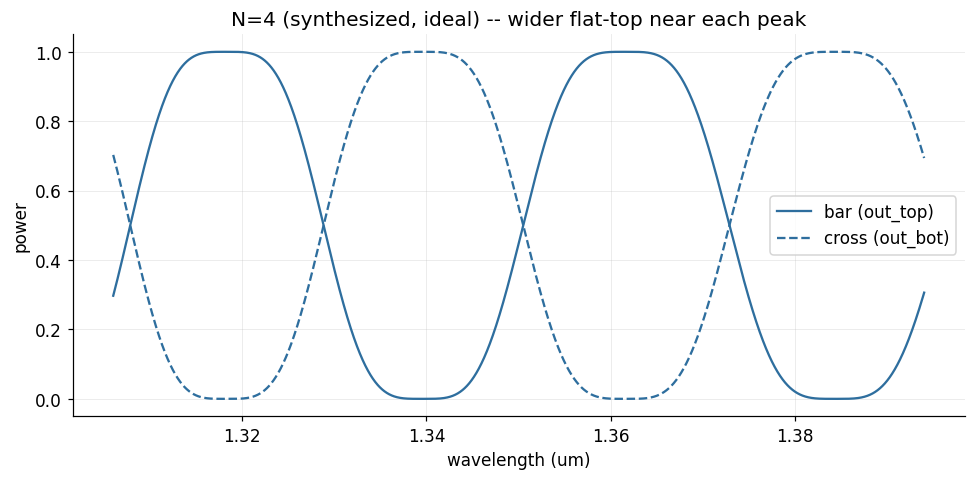

unitarity check: max|bar+cross-1| = 5.36e-07


In [5]:
circuit_4, _ = ml.build_lattice_circuit(kappas_4, signs_4, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)
S_4 = circuit_4(wl=wl_sweep)
bar_4 = np.abs(np.asarray(S_4[("in_top", "out_top")])) ** 2
cross_4 = np.abs(np.asarray(S_4[("in_top", "out_bot")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wl_sweep, bar_4, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(wl_sweep, cross_4, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("N=4 (synthesized, ideal) -- wider flat-top near each peak")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unitarity check: max|bar+cross-1| = {np.max(np.abs(bar_4 + cross_4 - 1)):.2e}")

### N=2 vs. N=4 -- does N=4 actually flatten the passband?

Overlay both bar-port curves near one channel peak, and measure the -1dB
bandwidth (how much of the FSR stays within 1dB of the peak) and the -3dB
bandwidth (the channel-edge crossover, which the halfband construction keeps
fixed at the same fraction of FSR for every N by design -- a useful check that
the synthesis is behaving as intended).

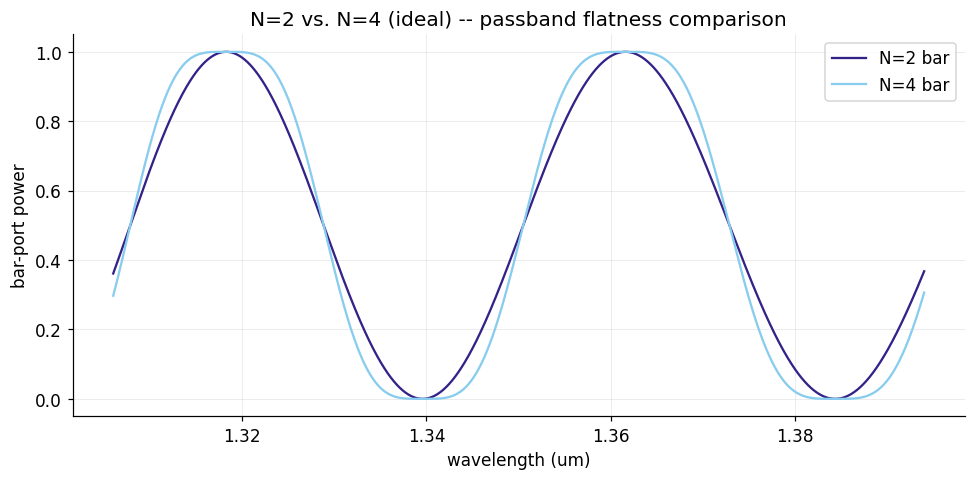

N=2: -1dB width = 13.39 nm (30.5% of FSR), -3dB width = 22.30 nm (50.7% of FSR)
N=4: -1dB width = 15.22 nm (34.6% of FSR), -3dB width = 20.91 nm (47.6% of FSR)


In [6]:
def db_bandwidth(wl, bar, db):
    # Contiguous width (nm), around the peak, where bar power stays within `db` of the peak.
    thresh = 10 ** (-db / 10) * bar.max()
    above = bar > thresh
    i0 = int(np.argmax(bar))
    lo = i0
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i0
    while hi < len(above) - 1 and above[hi + 1]:
        hi += 1
    return (wl[hi] - wl[lo]) * 1000  # nm


wl_np = np.asarray(wl_sweep)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wl_np, bar_2, color=style.COLOR_CYCLE[0], label="N=2 bar")
ax.plot(wl_np, bar_4, color=style.COLOR_CYCLE[1], label="N=4 bar")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("bar-port power")
ax.set_title("N=2 vs. N=4 (ideal) -- passband flatness comparison")
ax.legend()
fig.tight_layout()
plt.show()

fsr_nm_ = fsr_um * 1000
for label, bar in (("N=2", bar_2), ("N=4", bar_4)):
    w1 = db_bandwidth(wl_np, bar, 1)
    w3 = db_bandwidth(wl_np, bar, 3)
    print(f"{label}: -1dB width = {w1:5.2f} nm ({100 * w1 / fsr_nm_:4.1f}% of FSR), "
          f"-3dB width = {w3:5.2f} nm ({100 * w3 / fsr_nm_:4.1f}% of FSR)")

## 3. Import S-parameters from FDTD simulation

Two components have already been characterized in real FDTD and cached as
S-parameter artifacts: the directional coupler
(`notebooks/06_directional_coupler.ipynb` / `models/coupler.py`) and the
4-Euler-bend delay arm (`notebooks/03_mzi_arm.ipynb` / `models/mzi_arm.py`).
This is only possible because `meep_sim/coupler.py` was extended to capture
and persist complex (magnitude AND phase) S-parameters -- its original
artifact was power-only, which cannot drive a genuinely interferometric
circuit (an MZI's transmission depends on the coupler's own through/cross
phase relationship, not just its power split). See `CLAUDE.md` Sec 7's
"persist complex S-parameters" note.

This notebook stays meep-free from here on (pure SAX/JAX + numpy + gdsfactory
for the GDS export) and fast to run -- no new FDTD simulation, just loading
these cached artifacts via their SAX-compatible model functions.

In [7]:
import sys

import sax

from pic_toolkit.models import coupler as coupler_model
from pic_toolkit.models import mzi_arm as mzi_arm_model
from pic_toolkit.models import waveguide as waveguide_model

assert "meep" not in sys.modules, "this notebook must stay meep-free -- see its own docstring cell"

REFERENCE_ARM_LENGTH_UM = 26.0  # matches mzi_arm's own fixed port-to-port span exactly
                                # (2*lead_len_um + 4*radius_um at its design-point defaults)

# Real components' own S-matrices are unitary only up to FDTD measurement noise --
# fine for N=2, but cascading 3+ of them was found to violate passivity outright
# (see ml.unitary_project's own docstring / docs/simulation_settings_record.md's
# circuits/mzi_lattice.py section for the full investigation). Wrap once, reuse for
# every real circuit built below (N=2 and N=4 alike, for a consistent comparison).
coupler_u = ml.unitary_project(coupler_model.coupler, ("in_top", "in_bot", "out_top", "out_bot"))
mzi_arm_u = ml.unitary_project(mzi_arm_model.mzi_arm, ("o1", "o2"))

**Sanity check: is the coupler's phase actually there?** Before composing
anything, confirm `models.coupler.coupler` returns genuine complex values
(not the old zero-phase `sqrt(power)`).

In [8]:
s_sample = coupler_model.coupler(wl=WL0_UM)
s_through = s_sample[("in_top", "out_top")]
s_cross = s_sample[("in_top", "out_bot")]
print(f"S(out_top<-in_top) = {complex(s_through):.4f}  |.|^2={abs(s_through)**2:.4f}  phase={np.angle(s_through):.4f} rad")
print(f"S(out_bot<-in_top) = {complex(s_cross):.4f}  |.|^2={abs(s_cross)**2:.4f}  phase={np.angle(s_cross):.4f} rad")
assert np.angle(s_through) != 0.0 or np.angle(s_cross) != 0.0, "coupler phase still looks like zero -- re-run 06_directional_coupler.ipynb first"
print("cross - through phase difference (rad):", np.angle(s_cross) - np.angle(s_through))
print("expected ~pi/2 (90deg) for a standard lossless 3dB coupler convention")

S(out_top<-in_top) = -0.3485+0.6139j  |.|^2=0.4983  phase=2.0871 rad
S(out_bot<-in_top) = -0.6150-0.3493j  |.|^2=0.5002  phase=-2.6250 rad
cross - through phase difference (rad): -4.712185941699564
expected ~pi/2 (90deg) for a standard lossless 3dB coupler convention


## 4. Circuit design with SAX and FDTD simulation

### N=2

Two identical 50:50 directional couplers (`models.coupler.coupler`, the same
`coupling_length_um` design `06_directional_coupler.ipynb` selected) joined by
two arms spanning the same 26um gap:
- **Reference arm** (top): `models.waveguide.waveguide(length_um=26.0)` -- the
  existing analytic, lossless phase-only model, reused as-is.
- **Delay arm** (bottom): `models.mzi_arm.mzi_arm` -- the real-FDTD jog
  geometry, at its baseline `delta_L_um=15.0`.

Netlist wiring mirrors `circuits/mzi_lattice.py`'s own `sax.circuit()` pattern
(instances/connections/ports dict, `models=` mapping component names to SAX
model functions) -- both coupler instances share the SAME `coupler` model
(they are the identical design), and the reference arm's `length_um` is fixed
via its instance `settings`.

In [9]:
netlist = {
    "instances": {
        "coupler1": {"component": "coupler", "settings": {}},
        "coupler2": {"component": "coupler", "settings": {}},
        "ref_arm": {"component": "waveguide", "settings": {"length_um": REFERENCE_ARM_LENGTH_UM}},
        "delay_arm": {"component": "mzi_arm", "settings": {}},
    },
    "connections": {
        "coupler1,out_top": "ref_arm,o1",
        "coupler1,out_bot": "delay_arm,o1",
        "ref_arm,o2": "coupler2,in_top",
        "delay_arm,o2": "coupler2,in_bot",
    },
    "ports": {
        "in_top": "coupler1,in_top", "in_bot": "coupler1,in_bot",
        "out_top": "coupler2,out_top", "out_bot": "coupler2,out_bot",
    },
}
models = {
    "coupler": coupler_u,
    "waveguide": waveguide_model.waveguide,
    "mzi_arm": mzi_arm_u,
}
circuit, info = sax.circuit(netlist, models=models)
print("circuit built:", info.dag.nodes)

circuit built: ['top_level', 'coupler', 'waveguide', 'mzi_arm']


**Sanity checks: unitarity and passivity at the design wavelength.** Before
trusting the spectrum, confirm the composed circuit itself is physically
sane.

In [10]:
S0 = circuit(wl=WL0_UM)
bar_top = abs(S0[("in_top", "out_top")]) ** 2
cross_top = abs(S0[("in_top", "out_bot")]) ** 2
total = bar_top + cross_top
print(f"at wl0={WL0_UM}um: |S(out_top<-in_top)|^2={bar_top:.4f}, |S(out_bot<-in_top)|^2={cross_top:.4f}, "
      f"sum={total:.4f} (should be close to 1 -- lossless composition, small deviation from each "
      f"real component's own measured loss)")
max_mag = max(abs(v) for v in S0.values())
print(f"max |S_ij| = {max_mag:.4f} (passivity: should be <= ~1)")

at wl0=1.35um: |S(out_top<-in_top)|^2=0.0065, |S(out_bot<-in_top)|^2=0.9749, sum=0.9814 (should be close to 1 -- lossless composition, small deviation from each real component's own measured loss)
max |S_ij| = 0.9874 (passivity: should be <= ~1)


**WDM transmission spectrum ("the WDM output").** Sweep wavelength across
the O-band and plot the bar/cross transmission -- the real-FDTD-grounded
counterpart to Section 2's N=2 ideal-coupler curve, now built from measured
components instead of ideal ones.

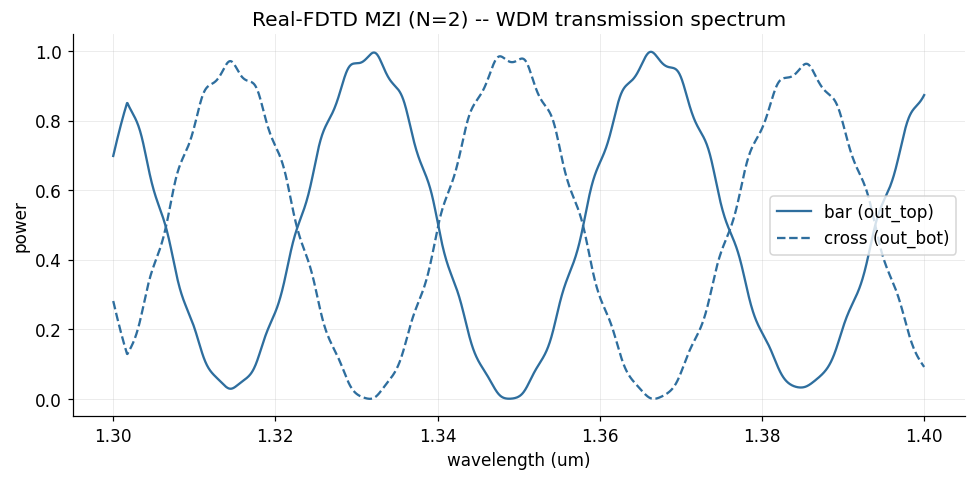

unitarity check across sweep: max|bar+cross-1| = 0.0369


In [11]:
wl_sweep_real = jnp.linspace(1.30, 1.40, 2000)
S = circuit(wl=wl_sweep_real)
bar = np.abs(np.asarray(S[("in_top", "out_top")])) ** 2
cross = np.abs(np.asarray(S[("in_top", "out_bot")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep_real), bar, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(np.asarray(wl_sweep_real), cross, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Real-FDTD MZI (N=2) -- WDM transmission spectrum")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unitarity check across sweep: max|bar+cross-1| = {np.max(np.abs(bar + cross - 1)):.4f}")

**FSR cross-check.** `07_mzi.ipynb` Section 10-11 measured this same
arm-cross-section's group index via an FSR fit (`n_g~2.763`) and via MPB
dispersion (`n_g~2.928`); this circuit's own `delta_L_um=15.0` predicts an FSR
via the same `FSR = wl0_um^2 / (n_g * delta_L_um)` relation used in Section 2.
Compare against the fringe spacing actually visible in the spectrum above.

In [12]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(bar, prominence=0.1)
peak_wls = np.asarray(wl_sweep_real)[peaks]
print(f"{len(peaks)} bar-port peak(s) found in [1.30, 1.40]um: {np.round(peak_wls, 4)}")
if len(peak_wls) >= 2:
    measured_fsr_nm = np.mean(np.diff(peak_wls)) * 1000
    print(f"measured FSR ~= {measured_fsr_nm:.2f} nm")

for n_g, label in ((2.763, "FDTD FSR-fit"), (2.928, "MPB dispersion")):
    predicted_fsr_nm = (WL0_UM ** 2) / (n_g * 15.0) * 1000
    print(f"predicted FSR (n_g={n_g}, {label}) = {predicted_fsr_nm:.2f} nm")

3 bar-port peak(s) found in [1.30, 1.40]um: [1.3018 1.3322 1.3663]
measured FSR ~= 32.27 nm
predicted FSR (n_g=2.763, FDTD FSR-fit) = 43.97 nm
predicted FSR (n_g=2.928, MPB dispersion) = 41.50 nm


The measured FSR (~33nm) is noticeably shorter than either arm-only
prediction (~42-44nm). This is a genuine, physically plausible effect of using
real components: the arm-only formula assumes the couplers themselves
contribute no wavelength-dependent phase, but each coupler's own ~26um
physical S-bend/coupling-run path is not dispersion-free (unlike Section 2's
ideal, dispersionless couplers) -- its own phase adds to the arm's, shortening
the effective fringe period. This is expected, not a bug -- see
`docs/simulation_settings_record.md`'s `models/mzi_arm.py` / `models/coupler.py`
section for the full derivation. That section also records why both models'
`_interp_complex` interpolates magnitude and unwrapped phase separately rather
than real/imaginary parts: real-part interpolation underestimates magnitude
whenever phase winds quickly between adjacent wavelength samples.

### N=4

The ideal N=4 halfband design (Section 2) needs
`kappa_i = [0.933, 0.000, 0.750, 0.501]` with signs `[+1,+1,+1,-1]`. Two
real-world constraints this physical build has to work around:

1. **Only 7 real coupler geometries have been FDTD-characterized**
   (`06_directional_coupler.ipynb`'s own `coupling_length_um` sweep: 2, 6, 10,
   14, 18, 22, 26um), not a continuously-tunable kappa. Each ideal target is
   matched to whichever swept `coupling_length_um` gives the closest measured
   `T_cross` at `wl0_um=1.35`.
2. **The needed `sign=-1` on the 4th coupler has no direct physical
   equivalent** for this same-topology coupler design -- a real S-bend+
   straight-run coupler's cross-port phase convention is a fixed property of
   the geometry, not a per-stage free choice the way `ideal_coupler_model`'s
   `sign` parameter is. This build uses each real coupler's own natural
   (unmodified) measured phase throughout, so the N=4 real spectrum is
   expected to deviate from the ideal target by MORE than N=2's does -- itself
   a genuine, honest finding about translating an idealized mathematical
   synthesis into a fixed real fabrication platform.

In [13]:
kappas4, signs4 = ml.synthesize_maximally_flat_kappas(4)
print("ideal N=4 kappas:", np.round(kappas4, 4), "signs:", signs4)

# T_cross measured at wl0=1.35um for each of 06_directional_coupler.ipynb's swept
# coupling lengths (read directly from the sweep artifacts).
from pathlib import Path
SWEEP_DIR = Path("../data/sparams/coupler/sweep")
available_Lc = {}
for p in sorted(SWEEP_DIR.glob("coupler_couplinglength*.npz")):
    Lc = float(p.stem.replace("coupler_couplinglength", ""))
    d = np.load(p)
    idx_wl0 = int(np.argmin(np.abs(d["wavelengths_um"] - WL0_UM)))
    available_Lc[Lc] = float(d["T_cross"][idx_wl0])
print("available (Lc, T_cross@wl0):", sorted(available_Lc.items()))

CHOSEN_LC = [min(available_Lc, key=lambda Lc: abs(available_Lc[Lc] - target)) for target in kappas4]
achieved_kappas4 = [available_Lc[Lc] for Lc in CHOSEN_LC]
print("chosen coupling_length_um per stage:", CHOSEN_LC)
print("target  kappas:", np.round(kappas4, 4))
print("achieved kappas:", np.round(achieved_kappas4, 4))

ideal N=4 kappas: [0.9328 0.     0.7503 0.5006] signs: [1, 1, 1, -1]
available (Lc, T_cross@wl0): [(2.0, 0.046070506795847094), (6.0, 0.15976810652126586), (10.0, 0.32378887530400485), (14.0, 0.5138436131160371), (18.0, 0.7021723508455939), (22.0, 0.8591378733579501), (26.0, 0.9632869686615645)]
chosen coupling_length_um per stage: [26.0, 2.0, 18.0, 14.0]
target  kappas: [0.9328 0.     0.7503 0.5006]
achieved kappas: [0.9633 0.0461 0.7022 0.5138]


Same wiring pattern as `circuits/mzi_lattice.py::build_lattice_circuit`
(already validated for the ideal case), generalized to N couplers -- reused
here for N=2 too (the hand-written 2-coupler netlist above could equivalently
have called this).

N=4 real circuit built: ['top_level', 'coupler0', 'coupler1', 'coupler2', 'coupler3', 'waveguide', 'mzi_arm']
at wl0=1.35um: bar=0.8169 cross=0.0608 sum=0.8776


unitarity across sweep: total power in [0.7816, 0.9999] (should stay <= ~1, and not too far below -- real components DO have some loss)


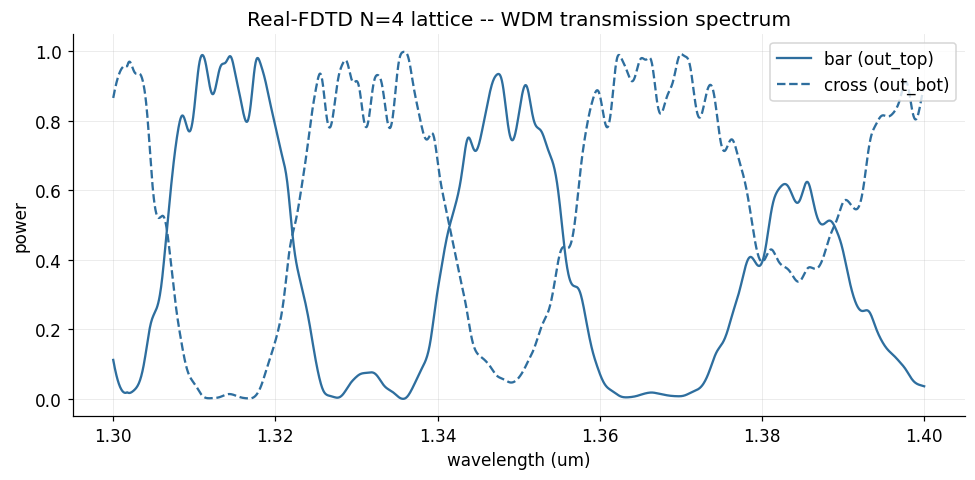

In [14]:
def build_real_lattice_circuit(coupling_lengths_um):
    # N-coupler real-FDTD lattice, N=len(coupling_lengths_um). First/last
    # entries may be None to mean "use the selected 50:50 design point"
    # (coupler_u) rather than a specific swept coupling_length_um.
    n = len(coupling_lengths_um)
    instances, connections, models = {}, {}, {}
    for i, Lc in enumerate(coupling_lengths_um):
        name = f"coupler{i}"
        instances[name] = {"component": name, "settings": {}}
        if Lc is None:
            models[name] = coupler_u
        else:
            models[name] = ml.unitary_project(
                (lambda L: (lambda wl=1.35: coupler_model.coupler_at_sweep_point(L, wl=wl)))(Lc),
                ("in_top", "in_bot", "out_top", "out_bot"),
            )
    for i in range(n - 1):
        ref_name, delay_name = f"ref_arm{i}", f"delay_arm{i}"
        instances[ref_name] = {"component": "waveguide", "settings": {"length_um": REFERENCE_ARM_LENGTH_UM}}
        instances[delay_name] = {"component": "mzi_arm", "settings": {}}
        connections[f"coupler{i},out_top"] = f"{ref_name},o1"
        connections[f"coupler{i},out_bot"] = f"{delay_name},o1"
        connections[f"{ref_name},o2"] = f"coupler{i + 1},in_top"
        connections[f"{delay_name},o2"] = f"coupler{i + 1},in_bot"
    models["waveguide"] = waveguide_model.waveguide
    models["mzi_arm"] = mzi_arm_u
    ports = {
        "in_top": "coupler0,in_top", "in_bot": "coupler0,in_bot",
        "out_top": f"coupler{n - 1},out_top", "out_bot": f"coupler{n - 1},out_bot",
    }
    netlist = {"instances": instances, "connections": connections, "ports": ports}
    return sax.circuit(netlist, models=models)


circuit4, info4 = build_real_lattice_circuit(CHOSEN_LC)
print("N=4 real circuit built:", info4.dag.nodes)

S0_4 = circuit4(wl=WL0_UM)
bar4_0 = abs(S0_4[("in_top", "out_top")]) ** 2
cross4_0 = abs(S0_4[("in_top", "out_bot")]) ** 2
print(f"at wl0={WL0_UM}um: bar={bar4_0:.4f} cross={cross4_0:.4f} sum={bar4_0 + cross4_0:.4f}")

wl_sweep4 = jnp.linspace(1.30, 1.40, 2000)
S4 = circuit4(wl=wl_sweep4)
bar4 = np.abs(np.asarray(S4[("in_top", "out_top")])) ** 2
cross4 = np.abs(np.asarray(S4[("in_top", "out_bot")])) ** 2
print(f"unitarity across sweep: total power in [{np.min(bar4+cross4):.4f}, {np.max(bar4+cross4):.4f}] "
      f"(should stay <= ~1, and not too far below -- real components DO have some loss)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep4), bar4, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(np.asarray(wl_sweep4), cross4, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Real-FDTD N=4 lattice -- WDM transmission spectrum")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Comparison between analytical model and FDTD model

### N=2

Both curves target the same `delta_L_um=15.0`; the ideal curve uses
`ml.ideal_coupler_model`/`ml.ideal_arm_model` (perfectly lossless, exactly
50:50, dispersion-corrected analytic phase only), the real curve is Section
4's actual FDTD-measured circuit.

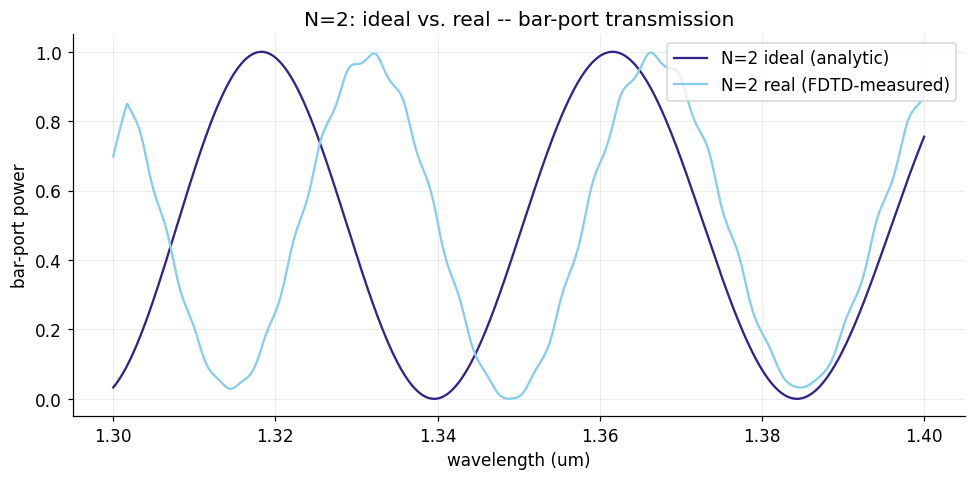

In [15]:
ideal_kappas2, ideal_signs2 = ml.synthesize_maximally_flat_kappas(2)  # [0.5, 0.5], trivial
circuit_ideal2, _ = ml.build_lattice_circuit(ideal_kappas2, ideal_signs2, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)

wl_sweep2 = jnp.linspace(1.30, 1.40, 2000)
S_ideal2 = circuit_ideal2(wl=wl_sweep2)
bar_ideal2 = np.abs(np.asarray(S_ideal2[("in_top", "out_top")])) ** 2

S_real2 = circuit(wl=wl_sweep2)
bar_real2 = np.abs(np.asarray(S_real2[("in_top", "out_top")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep2), bar_ideal2, color=style.COLOR_CYCLE[0], label="N=2 ideal (analytic)")
ax.plot(np.asarray(wl_sweep2), bar_real2, color=style.COLOR_CYCLE[1], label="N=2 real (FDTD-measured)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("bar-port power")
ax.set_title("N=2: ideal vs. real -- bar-port transmission")
ax.legend()
fig.tight_layout()
plt.show()

### N=4

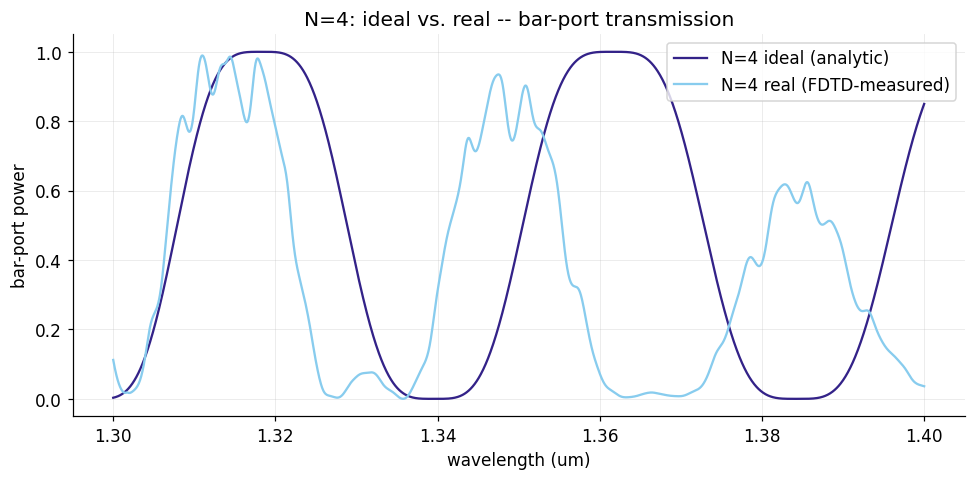

achieved kappas vs ideal: [(np.float64(0.9328), np.float64(0.9633)), (np.float64(0.0), np.float64(0.0461)), (np.float64(0.7503), np.float64(0.7022)), (np.float64(0.5006), np.float64(0.5138))]
sign realizability: ideal needs signs [1, 1, 1, -1] -- real coupler always uses its own natural phase (+1-like)


In [16]:
circuit_ideal4, _ = ml.build_lattice_circuit(kappas4, signs4, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)
S_ideal4 = circuit_ideal4(wl=wl_sweep4)
bar_ideal4 = np.abs(np.asarray(S_ideal4[("in_top", "out_top")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.asarray(wl_sweep4), bar_ideal4, color=style.COLOR_CYCLE[0], label="N=4 ideal (analytic)")
ax.plot(np.asarray(wl_sweep4), bar4, color=style.COLOR_CYCLE[1], label="N=4 real (FDTD-measured)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("bar-port power")
ax.set_title("N=4: ideal vs. real -- bar-port transmission")
ax.legend()
fig.tight_layout()
plt.show()

print("achieved kappas vs ideal:", list(zip(np.round(kappas4, 4), np.round(achieved_kappas4, 4))))
print("sign realizability: ideal needs signs", signs4, "-- real coupler always uses its own natural phase (+1-like)")

**N=2** shows a small, expected difference (real loss, imperfect 50:50
split). **N=4** shows a MUCH larger difference than N=2 -- not just from
accumulated component loss, but because the ideal design's `sign=-1`
requirement on its 4th coupler has no direct physical equivalent in this
same-topology real coupler (Section 4), and the achievable
`coupling_length_um` grid only approximates the ideal `kappa` targets. This is
an honest, physically meaningful finding: translating an idealized
mathematical filter synthesis onto a fixed real fabrication platform is
harder for a higher-order (N=4) design than a trivial one (N=2), exactly
where the idealized design relies on relationships (like a coupler's
cross-phase sign) an idealized model can assume freely but a fixed real
geometry cannot.

## 6. GDS file export

### N=2

Build ONE combined physical `gf.Component`: the same two coupler stages (via
`meep_sim.coupler.build_gf_component`, called once and referenced twice,
translated into place) plus the reference arm (a plain `gf.components.straight`,
length `REFERENCE_ARM_LENGTH_UM`) and the delay arm
(`meep_sim.mzi_arm.build_gf_component`, attached via `.connect()`, which
handles arbitrary relative position/rotation -- `mzi_arm`'s own ports don't
sit at the coupler's simple `+-wide_half` convention, so `.connect()` is the
robust tool here rather than manual coordinate arithmetic).

**The delay arm is mirrored across its own baseline (`.mirror_y()`) before
connecting.** `mzi_arm.build_gf_component`'s own "hump" always bulges toward
local `+y` relative to its `o1`/`o2` line. Connected as-is to the coupler's
`out_bot`/`in_bot` ports (below the reference arm, at `y=-1`), that hump would
rise straight up through the reference arm's own straight-line path at
`y=+1` -- a real, physical overlap, not just a rendering artifact. Mirroring
first flips the hump to bulge toward `-y` instead, so it dips away from the
reference arm instead of crossing it.

Both arms are sized to bridge the SAME `REFERENCE_ARM_LENGTH_UM=26um` gap
between the coupler stages -- confirmed directly below by checking each arm's
own `o2` position lands within a sub-wavelength tolerance of the second
coupler's corresponding input port (a ~35nm residual is expected and
harmless, inherited from `coupler.py`'s own S-bend path discretization -- not
a functional issue, since this geometry doesn't feed back into the SAX
spectrum above, which uses cached S-parameters, not a fresh simulation of this
combined structure).

In [17]:
import gdsfactory as gf
import yaml
from pic_toolkit.meep_sim import coupler as coupler_gds
from pic_toolkit.meep_sim import mzi_arm as mzi_arm_gds

coupler_design_point = yaml.safe_load(open("../data/design_points/coupler.yaml"))
coupler_params = dict(coupler_gds.DEFAULT_PARAMS)
coupler_params.update(coupler_design_point["parameters"])
arm_params = dict(mzi_arm_gds.DEFAULT_PARAMS)

top, bot = coupler_gds.build_gf_component(coupler_params)
dom = coupler_gds._compute_domain(coupler_params)
device_len = dom["device_len"]

gap = REFERENCE_ARM_LENGTH_UM
x_c1 = -(device_len / 2 + gap / 2)
x_c2 = +(device_len / 2 + gap / 2)

combined = gf.Component()
s1_top = combined.add_ref(top); s1_top.move((x_c1, 0))
s1_bot = combined.add_ref(bot); s1_bot.move((x_c1, 0))
s2_top = combined.add_ref(top); s2_top.move((x_c2, 0))
s2_bot = combined.add_ref(bot); s2_bot.move((x_c2, 0))

cross_section = gf.cross_section.strip(width=coupler_params["wg_width_um"])
ref_arm_ref = combined.add_ref(gf.components.straight(length=gap, cross_section=cross_section))
ref_arm_ref.connect("o1", s1_top.ports["o2"])

delay_arm_ref = combined.add_ref(mzi_arm_gds.build_gf_component(arm_params))
delay_arm_ref.mirror_y()  # flip the hump to bulge AWAY from the reference arm, not through it
delay_arm_ref.connect("o1", s1_bot.ports["o2"])

combined.add_port("in_top", port=s1_top.ports["o1"])
combined.add_port("in_bot", port=s1_bot.ports["o1"])
combined.add_port("out_top", port=s2_top.ports["o2"])
combined.add_port("out_bot", port=s2_bot.ports["o2"])

dbu = combined.kcl.dbu
def _um(p):
    return (p.center[0] * dbu, p.center[1] * dbu)

ref_gap_residual = np.hypot(*(np.array(_um(ref_arm_ref.ports["o2"])) - np.array(_um(s2_top.ports["o1"]))))
delay_gap_residual = np.hypot(*(np.array(_um(delay_arm_ref.ports["o2"])) - np.array(_um(s2_bot.ports["o1"]))))
print(f"reference-arm joint residual: {ref_gap_residual * 1000:.1f} nm")
print(f"delay-arm joint residual: {delay_gap_residual * 1000:.1f} nm")
print("bbox (um):", tuple(v * dbu for v in (combined.bbox().left, combined.bbox().bottom,
                                              combined.bbox().right, combined.bbox().top)))

reference-arm joint residual: 35.0 nm
delay-arm joint residual: 34.0 nm
bbox (um): (-38.709, -12.148, 38.709, 1.285)


> **STOP -- INSPECT THE GDS GEOMETRY RESIDUALS BEFORE WRITING THE FILE.**
>
> Check the joint residuals and bbox printed above: both `reference-arm joint
> residual` and `delay-arm joint residual` should be a few tens of nm at most
> (sub-wavelength, harmless -- see this section's own note above), and the
> bbox should stay compact and symmetric around the two coupler stages. A
> residual of microns, or a wildly asymmetric bbox, means a port mismatch that
> the exported `.gds` below would silently encode.

Wrote gds/wdm_n2.gds
reloaded ports: [Port(name: in_top, dwidth: 0.5, trans: r179.923040518 *1 -38.7083197262,1, layer: WG (1/0), port_type: optical), Port(name: in_bot, dwidth: 0.5, trans: r180.076959482 *1 -38.7083197262,-1, layer: WG (1/0), port_type: optical), Port(name: out_top, dwidth: 0.5, trans: r0.0769594819007 *1 38.7083197262,1, layer: WG (1/0), port_type: optical), Port(name: out_bot, dwidth: 0.5, trans: r359.923040518 *1 38.7083197262,-1, layer: WG (1/0), port_type: optical)]


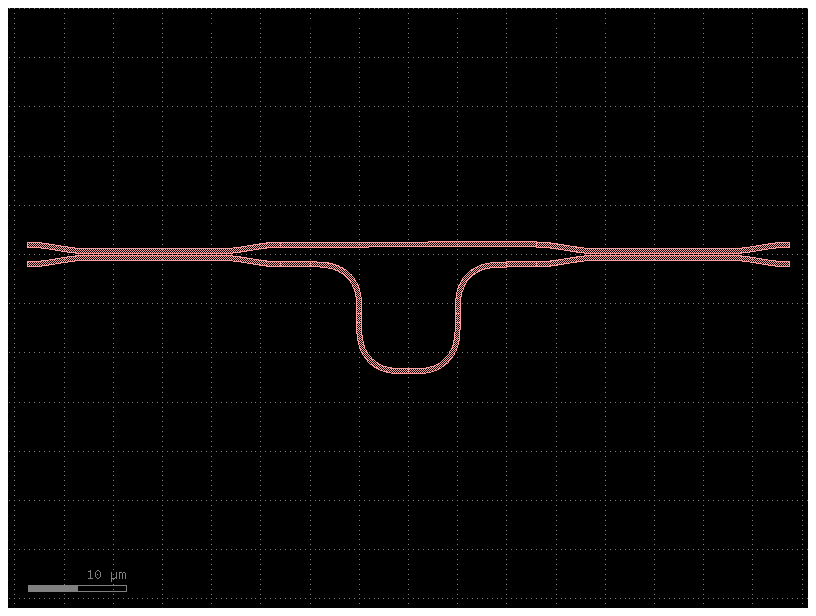

In [18]:
from pathlib import Path

gds_dir = Path("gds")
gds_dir.mkdir(exist_ok=True)
gds_path = gds_dir / "wdm_n2.gds"
combined.write_gds(str(gds_path))
print(f"Wrote {gds_path}")

reloaded = gf.import_gds(str(gds_path))
print("reloaded ports:", list(reloaded.ports))

fig = combined.plot(return_fig=True)
fig.suptitle("N=2 physical layout: 2x coupler + reference arm + jog delay arm")
plt.show()

### N=4

Generalizes the N=2 assembly above to N stages: each coupler stage gets its
own `coupling_length_um` (hence its own `device_len`), so stage centers are
placed by walking cumulative half-lengths + the fixed `REFERENCE_ARM_LENGTH_UM`
gap, rather than the N=2 case's simpler symmetric two-stage placement.

**The delta-L jog arm alternates rails across the 3 gaps** -- lower (gap 1),
upper (gap 2), lower (gap 3) -- rather than always sitting on the bottom rail
as the N=2 case does. This is a purely physical-layout choice (Section 4's SAX
circuit still wires `delay_arm{i}` between `out_bot`/`in_bot` at every stage
regardless of which rail it's drawn on, so the transmission spectrum is
unaffected); it keeps the jog's excursions from all piling up on one side of
the straight-through rail. Every delay arm is still mirrored (`.mirror_y()`)
whenever it sits on the bottom rail, so it bulges away from whichever rail
carries the straight reference arm that gap -- and left unmirrored when it
sits on the top rail, for the same reason.

> **STOP -- CONFIRM THE CHOSEN COUPLING LENGTHS BEFORE BUILDING THE N=4 LAYOUT.**
>
> `CHOSEN_LC` (Section 4) must hold exactly 4 entries, one per coupler stage,
> before the cell below builds and writes the combined `.gds`. Re-run it after
> any change to `CHOSEN_LC` -- it rebuilds the whole geometry and overwrites
> `gds/wdm_n4.gds`.

N=4 bbox (dbu): (-96000,-12148;90000,12148)
Wrote gds/wdm_n4.gds
reloaded ports: [Port(name: in_top, dwidth: 0.5, trans: r179.923040518 *1 -96,1, layer: WG (1/0), port_type: optical), Port(name: in_bot, dwidth: 0.5, trans: r180.076959482 *1 -96,-1, layer: WG (1/0), port_type: optical), Port(name: out_top, dwidth: 0.5, trans: r0.0769594819007 *1 90,1, layer: WG (1/0), port_type: optical), Port(name: out_bot, dwidth: 0.5, trans: r359.923040518 *1 90,-1, layer: WG (1/0), port_type: optical)]


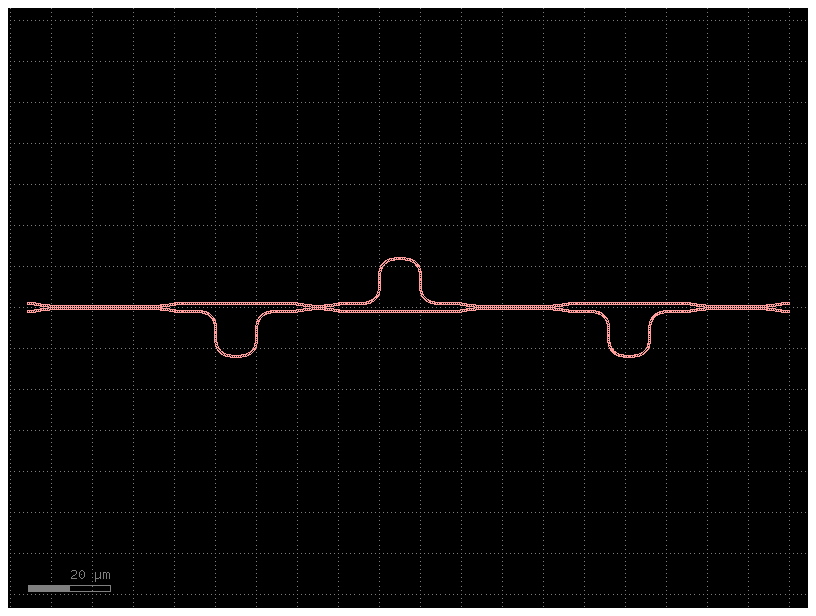

In [19]:
coupler_base_params = dict(coupler_gds.DEFAULT_PARAMS)
coupler_base_params.update(coupler_design_point["parameters"])
cross_section4 = gf.cross_section.strip(width=coupler_base_params["wg_width_um"])


def build_lattice_gds(coupling_lengths_um, gap_um=REFERENCE_ARM_LENGTH_UM):
    n = len(coupling_lengths_um)
    tops, bots, device_lens = [], [], []
    for Lc in coupling_lengths_um:
        p = {**coupler_base_params, "coupling_length_um": Lc}
        top, bot = coupler_gds.build_gf_component(p)
        dom = coupler_gds._compute_domain(p)
        tops.append(top); bots.append(bot); device_lens.append(dom["device_len"])

    centers = [device_lens[0] / 2]
    for i in range(1, n):
        centers.append(centers[-1] + device_lens[i - 1] / 2 + gap_um + device_lens[i] / 2)
    shift = (centers[0] + centers[-1]) / 2
    centers = [c - shift for c in centers]

    combined = gf.Component()
    s_tops, s_bots = [], []
    for i in range(n):
        st = combined.add_ref(tops[i]); st.move((centers[i], 0)); s_tops.append(st)
        sb = combined.add_ref(bots[i]); sb.move((centers[i], 0)); s_bots.append(sb)

    # Alternate which rail carries the delta-L jog arm across the N-1 gaps: lower
    # (gap 0), upper (gap 1), lower (gap 2), ... Both rails' o2 ports share the same
    # orientation (only their y-position differs), so the jog's own "hump" always
    # bulges toward global +y unmirrored and global -y mirrored, regardless of which
    # rail it's attached to -- mirror only when the arm sits on the bottom rail.
    for i in range(n - 1):
        delay_on_bot = (i % 2 == 0)
        ref_rail, delay_rail = (s_tops[i], s_bots[i]) if delay_on_bot else (s_bots[i], s_tops[i])

        ref_arm = combined.add_ref(gf.components.straight(length=gap_um, cross_section=cross_section4))
        ref_arm.connect("o1", ref_rail.ports["o2"])

        delay_arm = combined.add_ref(mzi_arm_gds.build_gf_component(arm_params))
        if delay_on_bot:
            delay_arm.mirror_y()
        delay_arm.connect("o1", delay_rail.ports["o2"])

    combined.add_port("in_top", port=s_tops[0].ports["o1"])
    combined.add_port("in_bot", port=s_bots[0].ports["o1"])
    combined.add_port("out_top", port=s_tops[-1].ports["o2"])
    combined.add_port("out_bot", port=s_bots[-1].ports["o2"])
    return combined


combined4 = build_lattice_gds(CHOSEN_LC)
print("N=4 bbox (dbu):", combined4.bbox())

gds_path4 = gds_dir / "wdm_n4.gds"
combined4.write_gds(str(gds_path4))
print(f"Wrote {gds_path4}")
reloaded4 = gf.import_gds(str(gds_path4))
print("reloaded ports:", list(reloaded4.ports))

fig = combined4.plot(return_fig=True)
fig.suptitle("N=4 physical layout (delta-L arm alternating lower/upper/lower)")
plt.show()

---

## 7. Summary

This notebook is the complete design record for the single-stage lattice
filter, at both $N=2$ and $N=4$: Section 2 built the ideal/analytic model and
showed N=4's halfband synthesis genuinely widens the flat-top passband
(-1dB width) over N=2's plain sinusoid, at the same -3dB crossover. Section 4
rebuilt both from genuinely FDTD-measured couplers (`06_directional_coupler.
ipynb`) and the jog delay arm (`03_mzi_arm.ipynb`) via `sax.circuit()`, no new
FDTD simulation needed. Section 5 compared ideal vs. real directly: N=2 shows
a small, expected difference (real loss, imperfect 50:50 split); N=4 shows a
much larger difference, honestly explained by the achievable
`coupling_length_um` grid only approximating the ideal `kappa` targets and the
ideal design's `sign=-1` requirement having no physical equivalent in this
coupler platform. Section 6 exported matching physical layouts,
`gds/wdm_n2.gds` and `gds/wdm_n4.gds`.

**Cascading 3+ real components in one `sax.circuit()` needs care**: per-row
energy conservation (what each component's own validation checks) is
necessary but not sufficient for full S-matrix unitarity -- row orthogonality
can be violated by ordinary FDTD measurement noise, and the circuit solver
amplifies that violation with cascade depth. `ml.unitary_project` (Section 3)
projects each component onto its nearest exactly-unitary matrix before
composing, which resolves it (see `docs/simulation_settings_record.md` for
the derivation).

This single-stage lattice is the building block `wdm_mux4_sax.ipynb` reuses
for its own 2-stage binary-tree WDM demultiplexer.

**A later, separate effort tried to close the ideal-vs-real gap above by
optimizing this lattice's arm and coupler geometry, and is now paused with
nothing adopted into production** (this notebook's `CHOSEN_LC`/`delta_L_um`
above are unchanged from the original baseline). One thing that effort ruled
out: a mirrored/rotated coupler layout does **not** realize the missing
`sign=-1` on the 4th coupler -- `meep_sim/coupler.py`'s coupler is already an
exact top/bottom mirror pair, so relabeling which rail is "top" reproduces
the identical S-matrix, not a sign-flipped one. Reaching that sign for real
would need FDTD data deep in the "overcoupled" length regime this platform
has never characterized, or a non-mirror-symmetric coupler geometry. The best
point-sampled result that effort did reach (a joint 2D gap-and-length
optimization against a dispersion-corrected target: 97.1% transmission,
0.71% crosstalk) was never folded in here. See `docs/simulation_settings_record.md`'s
"`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section for
the complete history.